![Databricks Academy](https://files.training.databricks.com/binder/prod_main/automated-deployment-with-declarative-automation-bundles-en_us-2.4.0/images/20260828T161450Z/Automated Deployment with Declarative Automation Bundles/Includes/images/common/db-academy.png)

# Lecture - Introduction to Declarative Automation Bundles (DABs)

## Overview

In this lecture, you will learn what a Declarative Automation Bundle is, how it works through the Databricks CLI, and where bundles are used. You will look at the standard bundle project structure, the `databricks.yml` configuration file with its top-level mappings, and the three CLI commands used to validate, deploy, and run a bundle. These fundamentals are used in every demo and lab that follows.

## Learning Objectives

By the end of this lecture, you will be able to:
1. **Describe** what Declarative Automation Bundles are and where they are used.
2. **Identify** the standard structure of a DAB project.
3. **Explain** the top-level mappings of the `databricks.yml` configuration file.
4. **Use** the Databricks CLI to validate, deploy, and run a bundle.

## A. What Are Declarative Automation Bundles?

### A1. DABs in Three Questions

Build up the definition of a DAB by answering three questions. Click each tab.
<div style="max-width:1100px;margin:0 auto;font-family:sans-serif;">
<style>
.tb1-tabbar { display:flex; border-bottom:2px solid #EEEDE9; flex-wrap:wrap; }
.tb1-tab { padding:10px 20px; border:none; border-bottom:3px solid transparent; background:none; font-size:14pt; font-weight:bold; color:#888; cursor:pointer; margin-bottom:-2px; }
.tb1-tab-active-1 { color:#4299E0; border-bottom-color:#4299E0; }
.tb1-tab-active-2 { color:#00A972; border-bottom-color:#00A972; }
.tb1-tab-active-3 { color:#FFAB00; border-bottom-color:#FFAB00; }
.tb1-panel { display:none; margin-top:16px; } .tb1-panel-active { display:block; }
</style>
<div class="tb1-tabbar"><button class="tb1-tab" onclick="tb1Show(1)">What are they?</button><button class="tb1-tab" onclick="tb1Show(2)">How do they work?</button><button class="tb1-tab" onclick="tb1Show(3)">Where are they used?</button></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #4299E0;padding:20px 24px;"><div style="display:flex;align-items:center;gap:10px;font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">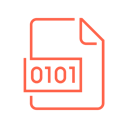 Write code once, deploy everywhere</div><p style="font-size:14pt;color:#0b2026;">DABs use <strong>YAML files</strong> to specify the artifacts, resources, and configurations of a Databricks project.</p></div></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #00A972;padding:20px 24px;"><div style="display:flex;align-items:center;gap:10px;font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">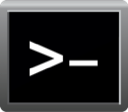 Through the Databricks CLI</div><p style="font-size:14pt;color:#0b2026;">The new <code>databricks</code> CLI has specific <strong>bundle commands</strong> to validate, deploy, and run Declarative Automation Bundles using a bundle YAML file.</p></div></div>
<div class="tb1-panel"><div style="background:#F9F7F4;border-radius:8px;box-shadow:0 2px 8px rgba(27,49,57,0.06);border-top:6px solid #FFAB00;padding:20px 24px;"><div style="display:flex;align-items:center;gap:10px;font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:8px;">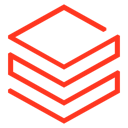 Development and CI/CD</div><p style="font-size:14pt;color:#0b2026;">Bundles are extremely useful during <strong>development and CI/CD processes</strong> to deploy Databricks assets to specified environments.</p></div></div>
</div>
<script>
function tb1Show(n){var t=document.getElementsByClassName("tb1-tab"),p=document.getElementsByClassName("tb1-panel");
for(var i=0;i<t.length;i++){t[i].className="tb1-tab";p[i].className="tb1-panel";}
p[n-1].className="tb1-panel tb1-panel-active"; t[n-1].className="tb1-tab tb1-tab-active-"+n;}
window.addEventListener('load',function(){ tb1Show(1); });
</script>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- DABs enable us to write code once and deploy everywhere. But what exactly are they?
- DABs (Declarative Automation Bundles) use YAML files to specify the artifacts, resources, and configurations of a Databricks project. They allow us to manage and deploy all the necessary components of a Databricks project in a consistent and efficient way to multiple environments.
- How exactly do DABs work?
- The new Databricks CLI has specific bundle commands to validate, deploy, and run Declarative Automation Bundles using a YAML file. We will learn how to do this throughout the course.
- So, where are Declarative Automation Bundles used?
- DABs are extremely useful during development and CI/CD processes for deploying Databricks assets to target environments, while modifying specific configurations for each environment. We will see how to do this throughout the course.

</details>

### A2. CI/CD with DABs Overview

The big-picture workflow: a bundle moves from a local environment through version control and CI/CD into development, staging, and production workspaces.

<div style="text-align:center;"><svg viewBox="0 0 1120 640" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;max-width:1120px;font-family:Helvetica,Arial,sans-serif;">
  <defs>
    <marker id="a2ah" markerWidth="9" markerHeight="9" refX="6" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L6,3 L0,6 Z" fill="#FF5F46"/></marker>
  </defs>

  <!-- ===== arrows (drawn first, under boxes) ===== -->
  <!-- bundle fans out to dev deployment (up) and project repository (down) -->
  <path d="M300,255 L452,205" stroke="#FF5F46" stroke-width="3" fill="none" marker-end="url(#a2ah)"/>
  <path d="M300,262 L340,500" stroke="#FF5F46" stroke-width="3" fill="none" marker-end="url(#a2ah)"/>
  <!-- CI/CD fans out from a common origin to staging and production (V shape, like the slide) -->
  <path d="M840,443 L792,244" stroke="#FF5F46" stroke-width="3" fill="none" marker-end="url(#a2ah)"/>
  <path d="M840,443 L1002,244" stroke="#FF5F46" stroke-width="3" fill="none" marker-end="url(#a2ah)"/>

  <!-- ===== Data workers ===== -->
  <rect x="8" y="6" width="120" height="24" fill="#F1EEE9"/>
  <text x="18" y="23" font-family="Helvetica,Arial,sans-serif" font-size="13" fill="#0b2026" text-anchor="start">Data workers</text>
  <image href="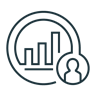" x="24" y="38" width="38" height="38" preserveAspectRatio="xMidYMid meet"/>
  <image href="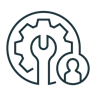" x="80" y="38" width="38" height="38" preserveAspectRatio="xMidYMid meet"/>

  <!-- ===== Local development environment ===== -->
  <rect x="8" y="92" width="300" height="256" rx="10" fill="none" stroke="#4299E0" stroke-width="1.5" stroke-dasharray="5 4"/>
  <text x="22" y="118" font-family="Helvetica,Arial,sans-serif" font-size="13.5" font-weight="700" fill="#1B5162" text-anchor="start">Local development environment</text>
  <image href="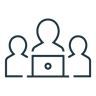" x="105" y="128" width="36" height="36" preserveAspectRatio="xMidYMid meet"/>
  <image href="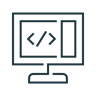" x="170" y="128" width="36" height="36" preserveAspectRatio="xMidYMid meet"/>
  <rect x="24" y="180" width="268" height="92" rx="10" fill="none" stroke="#4299E0" stroke-width="1.5"/>
  <text x="158" y="200" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#1B5162" text-anchor="middle">Project Bundle</text>
  <image href="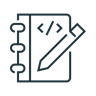" x="60" y="214" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="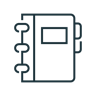" x="122" y="214" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="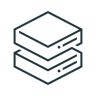" x="184" y="214" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="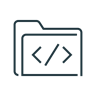" x="246" y="214" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="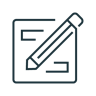" x="20" y="292" width="28" height="28" preserveAspectRatio="xMidYMid meet"/>
  <text x="54" y="300" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">Users can do direct edits for items</text><text x="54" y="315" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">that aren't source controlled</text>

  <!-- ===== Databricks workspaces ===== -->
  <rect x="440" y="40" width="672" height="230" rx="10" fill="none" stroke="#FF5F46" stroke-width="1.5" stroke-dasharray="5 4"/>
  <image href="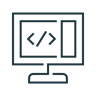" x="690" y="50" width="26" height="26" preserveAspectRatio="xMidYMid meet"/>
  <text x="726" y="68" font-family="Helvetica,Arial,sans-serif" font-size="15" font-weight="700" fill="#1B5162" text-anchor="start">Databricks workspaces</text>
  <!-- dev workspace -->
  <rect x="455" y="88" width="205" height="168" rx="10" fill="none" stroke="#FF5F46" stroke-width="1.5"/>
  <text x="557" y="112" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">Development</text><text x="557" y="129" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">workspace</text>
  <rect x="470" y="150" width="175" height="90" rx="8" fill="none" stroke="#4299E0" stroke-width="1.5"/>
  <text x="557" y="190" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">Development</text><text x="557" y="207" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">deployment</text>
  <!-- staging workspace -->
  <rect x="678" y="88" width="205" height="168" rx="10" fill="none" stroke="#FF5F46" stroke-width="1.5"/>
  <text x="780" y="112" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">Staging</text><text x="780" y="129" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">workspace</text>
  <rect x="693" y="150" width="175" height="90" rx="8" fill="none" stroke="#4299E0" stroke-width="1.5"/>
  <text x="780" y="190" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">Staging</text><text x="780" y="207" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">deployment</text>
  <!-- prod workspace -->
  <rect x="901" y="88" width="205" height="168" rx="10" fill="none" stroke="#FF5F46" stroke-width="1.5"/>
  <text x="1003" y="112" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">Production</text><text x="1003" y="129" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">workspace</text>
  <rect x="916" y="150" width="175" height="90" rx="8" fill="none" stroke="#4299E0" stroke-width="1.5"/>
  <text x="1003" y="190" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">Production</text><text x="1003" y="207" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#1B5162" text-anchor="middle">deployment</text>

  <!-- ===== middle annotations (positioned as on the slide) ===== -->
  <!-- manual deploy: in the gap left of the dev workspace, above the bundle->dev arrow -->
  <image href="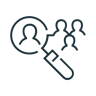" x="360" y="286" width="34" height="34" preserveAspectRatio="xMidYMid meet"/>
  <text x="400" y="298" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">Users can manually deploy</text><text x="400" y="314" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">to see and test changes in dev</text>
  <!-- code+integration tests: lower and further right (mid of diagram, like the slide) -->
  <image href="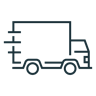" x="560" y="372" width="34" height="34" preserveAspectRatio="xMidYMid meet"/>
  <text x="600" y="384" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">Code and integration tests</text><text x="600" y="400" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">are deployed to staging</text>
  <!-- code to production: right side, near the production arrow -->
  <image href="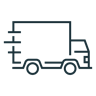" x="905" y="330" width="34" height="34" preserveAspectRatio="xMidYMid meet"/>
  <text x="945" y="342" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">Code is deployed to</text><text x="945" y="358" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">production after review</text><text x="945" y="374" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">and approval</text>

  <!-- ===== bottom row ===== -->
  <image href="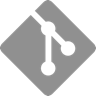" x="12" y="470" width="34" height="34" preserveAspectRatio="xMidYMid meet"/>
  <text x="54" y="482" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">Users can commit changes to</text><text x="54" y="498" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0b2026" text-anchor="start">source control</text>
  <!-- version control -->
  <rect x="332" y="446" width="220" height="118" rx="12" fill="none" stroke="#1B3139" stroke-width="1.5"/>
  <text x="442" y="472" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#1B5162" text-anchor="middle">Version Control</text>
  <rect x="348" y="490" width="188" height="56" rx="8" fill="none" stroke="#1B3139" stroke-width="1.5"/>
  <text x="442" y="523" font-family="Helvetica,Arial,sans-serif" font-size="12.5" font-weight="700" fill="#1B5162" text-anchor="middle">Project Repository</text>
  <text x="578" y="498" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">Notifications</text><text x="578" y="514" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">trigger CI/CD &#8594;</text>
  <!-- CI/CD -->
  <rect x="718" y="446" width="394" height="118" rx="12" fill="none" stroke="#FF5F46" stroke-width="1.5" stroke-dasharray="5 4"/>
  <text x="915" y="472" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#1B5162" text-anchor="middle">CI/CD</text>
  <image href="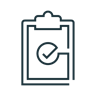" x="740" y="494" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="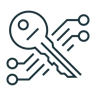" x="792" y="494" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <image href="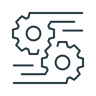" x="844" y="494" width="32" height="32" preserveAspectRatio="xMidYMid meet"/>
  <text x="888" y="502" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">Configure service principles,</text><text x="888" y="518" font-family="Helvetica,Arial,sans-serif" font-size="11.5" fill="#0b2026" text-anchor="start">kick off jobs, and other tasks</text>
</svg></div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Let's take a look at the following diagram, which provides a high-level view of a development and CI/CD pipeline with bundles.
- If you're working locally, you'll build the project bundle with your team using a local environment setup (or you can do this within your Databricks Workspace).
- From here, you can either use bundles or manually deploy to your development environment, which can include a development workspace or catalogs. This is where you can test your changes away from production.
- After development, users can then commit changes to version control within a project repository and push your development changes.
- After the changes are committed, you can set a notification to trigger to initiate the CI/CD pipeline. In a typical pipeline, the tests are first deployed to a staging environment.
- Once all tests pass in staging, the code can then be deployed to the production environment after following your organization's processes, such as code review and approval.

</details>

## B. Simple Project Structure

### B1. Simple Project Structure Overview

A bundle project has a predictable folder layout. The tree on the left maps to what each folder holds; the required `databricks.yml` file drives the whole bundle.
<div style="display:flex;gap:26px;flex-wrap:wrap;max-width:1120px;margin:0 auto;font-family:sans-serif;align-items:flex-start;">
  <div style="flex:0 0 300px;border:1.5px solid #1B3139;border-radius:6px;padding:22px 20px;position:relative;">
    <div style="position:absolute;top:14px;right:16px;">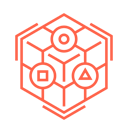</div>
    <div style="font-weight:700;font-size:15pt;color:#0b2026;font-family:Consolas,Monaco,monospace;padding-left:0px;">my_project/</div>
    <div style="font-weight:400;font-size:15pt;color:#0b2026;font-family:Consolas,Monaco,monospace;padding-left:24px;">&#9492;&#9472; resources/</div>
    <div style="font-weight:400;font-size:15pt;color:#0b2026;font-family:Consolas,Monaco,monospace;padding-left:24px;">&#9492;&#9472; src/</div>
    <div style="font-weight:400;font-size:15pt;color:#0b2026;font-family:Consolas,Monaco,monospace;padding-left:24px;">&#9492;&#9472; tests/</div>
    <div style="font-weight:400;font-size:15pt;color:#0b2026;font-family:Consolas,Monaco,monospace;padding-left:24px;">&#9492;&#9472; <b>databricks.yml</b></div>
  </div>
  <div style="flex:1 1 380px;min-width:320px;display:flex;flex-direction:column;gap:12px;">
    <div style="border:1px solid #FF5F46;border-radius:6px;padding:12px 16px;font-size:13.5pt;color:#0b2026;background:#fff;"><b>resources/</b> &mdash; Additional YAML configuration files for your Declarative Automation Bundles</div>
    <div style="border:1px solid #FF5F46;border-radius:6px;padding:12px 16px;font-size:13.5pt;color:#0b2026;background:#fff;"><b>src/</b> &mdash; Contains the <b>source files (notebooks, python files, etc)</b> needed for the data pipeline</div>
    <div style="border:1px solid #FF5F46;border-radius:6px;padding:12px 16px;font-size:13.5pt;color:#0b2026;background:#fff;"><b>tests/</b> &mdash; Contains <b>unit and integration tests</b> for the data pipeline</div>
  </div>
</div>
<div style="max-width:1120px;margin:18px auto 0 auto;font-family:sans-serif;">
  <div style="background:#F9F7F4;border:2px dashed #FF5F46;border-radius:8px;padding:16px 20px;">
    <div style="font-size:15pt;font-weight:700;color:#0b2026;margin-bottom:8px;"><b>databricks.yml</b> &mdash; REQUIRED bundle configuration file that must:</div>
    <ul style="margin:0;padding-left:22px;font-size:14pt;color:#0b2026;line-height:1.6;">
      <li>be expressed in <b>YAML format</b></li>
      <li>contain at minimum the <b>top-level bundle mapping</b></li>
      <li>contain at minimum one (and only one) bundle configuration file named <b>databricks.yml</b></li>
    </ul>
  </div>
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Now that we have a good overview of the CI/CD process, let's dive into a typical, simple project structure for your bundle.
- In your project folder, you'll want to create multiple subfolders to organize your assets. A simple project structure should start with your project folder, followed by various folders and files, such as resources, src, tests, and a main databricks.yml file. These folders may contain additional subfolders to store specific files.
- The resources folder should contain additional YAML configuration files for your Declarative Automation Bundles, if needed.
- The src (or source) folder contains the source files needed for your data pipeline, such as notebooks and Python files.
- The tests folder contains your unit and integration tests for the pipeline.
- Organizing and modularizing your folders and files will help you during development and maintenance as your project grows.
- This is a simple example, and your project may have additional files and folders, or a different organizational structure.
- The databricks.yml file is a required bundle configuration file used to deploy your Databricks assets. This file must: be expressed in YAML format; contain at minimum the top-level bundle mapping; and contain at least one (and only one) bundle configuration file named databricks.yml.

</details>

## C. The databricks.yml Configuration File

### C1. Top-Level Mappings

The `databricks.yml` configuration file's top-level mappings are left-aligned keys. This example uses **bundle**, **resources**, and **targets**; other mappings are available for more advanced configuration.
<div style="max-width:1150px;margin:0 auto 16px auto;font-family:sans-serif;">
  <div style="font-size:14pt;color:#0b2026;margin-bottom:10px;">The <code>databricks.yml</code> configuration top level mappings include:</div>
  <div style="display:flex;flex-wrap:wrap;gap:8px;">
    <span style="background:rgba(255,95,70,0.15);border:1px solid #FF5F46;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;font-weight:700;">bundle</span><span style="background:rgba(255,95,70,0.15);border:1px solid #FF5F46;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;font-weight:700;">resources</span><span style="background:rgba(255,95,70,0.15);border:1px solid #FF5F46;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;font-weight:700;">targets</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">variables</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">workspace</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">permissions</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">artifacts</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">include</span><span style="background:rgba(255,95,70,0.08);border:1px solid #618794;border-radius:16px;padding:6px 16px;font-size:14pt;color:#0b2026;">sync</span>
  </div>
</div>


<style>
.c1wrap { display:grid; grid-template-columns:minmax(240px, 0.85fr) minmax(0, 1.15fr); gap:18px; max-width:1150px; margin:0 auto; font-family:sans-serif; align-items:start; }
.c1left { display:flex; flex-direction:column; gap:10px; min-width:0; }
.c1card { background:#F9F7F4; border-radius:8px; padding:11px 14px; cursor:pointer; border-left:6px solid var(--cc); box-shadow:0 2px 8px rgba(27,49,57,0.06); transition:transform .1s; user-select:none; }
.c1card:hover { transform:translateX(3px); }
.c1card.active { background:#fff; outline:2px solid var(--cc); }
.c1lbl { font-weight:700; font-size:13.5pt; color:var(--cc); }
.c1sub { font-size:12.5pt; color:#0b2026; margin-top:3px; line-height:1.4; }
.c1right { min-width:0; }
.c1pre { background:#f8f8f8; border:1px solid #e0e0e0; border-radius:8px; padding:14px 16px; margin:0; overflow-x:auto; font-family:Consolas,Monaco,monospace; font-size:12pt; line-height:1.5; color:#1B3139; }
.c1ln { display:block; white-space:pre; padding:0 6px; border-radius:3px; transition:background .15s; }
.c1hint { font-size:12pt;color:#5E7077;font-style:italic;margin-bottom:8px; }
@media (max-width:780px){ .c1wrap{ grid-template-columns:1fr; } }
</style><div class="c1wrap"><div class="c1left"><div class="c1hint">Click an item to highlight it in the code &rarr;</div><div class="c1card" data-lines="0,1" data-idx="0" style="--cc:#4299E0;" onclick="c1sel(0)"><div class="c1lbl">bundle</div><div class="c1sub">Identity of the bundle &mdash; declares the required bundle name.</div></div><div class="c1card" data-lines="3,4,5,6,7,8,9,10,11" data-idx="1" style="--cc:#00A972;" onclick="c1sel(1)"><div class="c1lbl">resources</div><div class="c1sub">The Databricks objects the bundle manages (jobs, pipelines, MLflow&hellip;), defined with REST API parameters.</div></div><div class="c1card" data-lines="13,14,15,16,17,18,19,20,21,22" data-idx="2" style="--cc:#FFAB00;" onclick="c1sel(2)"><div class="c1lbl">targets</div><div class="c1sub">Environments and their configuration overrides (dev, production&hellip;).</div></div></div><div class="c1right"><pre class="c1pre"><span class="c1ln" data-ln="0">bundle:</span><span class="c1ln" data-ln="1">  name: demo01_bundle</span><span class="c1ln" data-ln="2"> </span><span class="c1ln" data-ln="3">resources:</span><span class="c1ln" data-ln="4">  jobs:</span><span class="c1ln" data-ln="5">    l1_simple_dab:</span><span class="c1ln" data-ln="6">      name: my_job_name_l1_simple_dab</span><span class="c1ln" data-ln="7">      tasks:</span><span class="c1ln" data-ln="8">        - task_key: create_bronze_table</span><span class="c1ln" data-ln="9">          notebook_task:</span><span class="c1ln" data-ln="10">            notebook_path: ./src/create_bronze_table.py</span><span class="c1ln" data-ln="11">            source: WORKSPACE</span><span class="c1ln" data-ln="12">. . .</span><span class="c1ln" data-ln="13">targets:</span><span class="c1ln" data-ln="14">  development:</span><span class="c1ln" data-ln="15">    mode: development</span><span class="c1ln" data-ln="16">    default: true</span><span class="c1ln" data-ln="17">    workspace:</span><span class="c1ln" data-ln="18">      host: https://dev.cloud.databricks.com/</span><span class="c1ln" data-ln="19">  production:</span><span class="c1ln" data-ln="20">    mode: production</span><span class="c1ln" data-ln="21">    workspace:</span><span class="c1ln" data-ln="22">      host: https://prod.cloud.databricks.com/</span></pre></div></div>
<script>
(function(){
  var COLORS=['rgba(66,153,224,0.22)', 'rgba(0,169,114,0.22)', 'rgba(255,171,0,0.22)'];
  window.c1sel=function(idx){
    var lns=document.querySelectorAll('.c1ln');
    lns.forEach(function(s){ s.style.background=''; });
    document.querySelectorAll('.c1card').forEach(function(c){ c.classList.remove('active'); });
    var card=document.querySelector('.c1card[data-idx="'+idx+'"]');
    if(!card) return; card.classList.add('active');
    var set=card.getAttribute('data-lines').split(',');
    var col=COLORS[idx];
    set.forEach(function(n){ var s=document.querySelector('.c1ln[data-ln="'+n+'"]'); if(s) s.style.background=col; });
  };
  window.addEventListener('load',function(){ window.c1sel(0); });
})();
</script>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- The databricks.yml file is key to your bundle. Let's take a look at a simple example.
- First, the YAML file contains several top-level mapping keys that are left-aligned. In this example databricks.yml file, it includes the top-level mappings: bundle, resources, and targets.
- Other top-level mappings include variables, workspace, permissions, artifacts, include, and sync. We will cover many of these top-level mappings in this course.

</details>

### C2. The bundle and resources Mappings

The **bundle** mapping declares a required bundle name (and can carry other optional configurations). The **resources** mapping defines the Databricks resources used by the bundle, using the corresponding Databricks REST API parameters.


<style>
.c2wrap { display:grid; grid-template-columns:minmax(240px, 0.85fr) minmax(0, 1.15fr); gap:18px; max-width:1150px; margin:0 auto; font-family:sans-serif; align-items:start; }
.c2left { display:flex; flex-direction:column; gap:10px; min-width:0; }
.c2card { background:#F9F7F4; border-radius:8px; padding:11px 14px; cursor:pointer; border-left:6px solid var(--cc); box-shadow:0 2px 8px rgba(27,49,57,0.06); transition:transform .1s; user-select:none; }
.c2card:hover { transform:translateX(3px); }
.c2card.active { background:#fff; outline:2px solid var(--cc); }
.c2lbl { font-weight:700; font-size:13.5pt; color:var(--cc); }
.c2sub { font-size:12.5pt; color:#0b2026; margin-top:3px; line-height:1.4; }
.c2right { min-width:0; }
.c2pre { background:#f8f8f8; border:1px solid #e0e0e0; border-radius:8px; padding:14px 16px; margin:0; overflow-x:auto; font-family:Consolas,Monaco,monospace; font-size:12pt; line-height:1.5; color:#1B3139; }
.c2ln { display:block; white-space:pre; padding:0 6px; border-radius:3px; transition:background .15s; }
.c2hint { font-size:12pt;color:#5E7077;font-style:italic;margin-bottom:8px; }
@media (max-width:780px){ .c2wrap{ grid-template-columns:1fr; } }
</style><div class="c2wrap"><div class="c2left"><div class="c2hint">Click an item to highlight it in the code &rarr;</div><div class="c2card" data-lines="0,1" data-idx="0" style="--cc:#4299E0;" onclick="c2sel(0)"><div class="c2lbl">bundle name</div><div class="c2sub">The <b>bundle</b> top level mapping declares a required bundle name, and can use other optional configurations.</div></div><div class="c2card" data-lines="3,4" data-idx="1" style="--cc:#00A972;" onclick="c2sel(1)"><div class="c2lbl">resources</div><div class="c2sub">Defines the Databricks resources used by the bundle &mdash; Lakeflow Jobs, Spark Declarative Pipelines, MLflow, and more &mdash; using the corresponding Databricks REST API.</div></div><div class="c2card" data-lines="5" data-idx="2" style="--cc:#98102A;" onclick="c2sel(2)"><div class="c2lbl">Job key</div><div class="c2sub">The resource mapping name (job key) &mdash; must be unique.</div></div><div class="c2card" data-lines="6" data-idx="3" style="--cc:#FFAB00;" onclick="c2sel(3)"><div class="c2lbl">Job Name</div><div class="c2sub">The <code>name</code> mapping sets the actual job name created in the workspace.</div></div><div class="c2card" data-lines="7,8,9,10,11" data-idx="4" style="--cc:#618794;" onclick="c2sel(4)"><div class="c2lbl">tasks &middot; notebook</div><div class="c2sub">Each task uses <code>notebook_path</code> (a relative path with the correct extension) to specify the notebook to run.</div></div></div><div class="c2right"><pre class="c2pre"><span class="c2ln" data-ln="0">bundle:</span><span class="c2ln" data-ln="1">  name: demo01_bundle</span><span class="c2ln" data-ln="2"> </span><span class="c2ln" data-ln="3">resources:</span><span class="c2ln" data-ln="4">  jobs:</span><span class="c2ln" data-ln="5">    l1_simple_dab:</span><span class="c2ln" data-ln="6">      name: my_job_name_l1_simple_dab</span><span class="c2ln" data-ln="7">      tasks:</span><span class="c2ln" data-ln="8">        - task_key: create_bronze_table</span><span class="c2ln" data-ln="9">          notebook_task:</span><span class="c2ln" data-ln="10">            notebook_path: ./src/create_bronze_table.py</span><span class="c2ln" data-ln="11">            source: WORKSPACE</span></pre></div></div>
<script>
(function(){
  var COLORS=['rgba(66,153,224,0.22)', 'rgba(0,169,114,0.22)', 'rgba(152,16,42,0.22)', 'rgba(255,171,0,0.22)', 'rgba(97,135,148,0.22)'];
  window.c2sel=function(idx){
    var lns=document.querySelectorAll('.c2ln');
    lns.forEach(function(s){ s.style.background=''; });
    document.querySelectorAll('.c2card').forEach(function(c){ c.classList.remove('active'); });
    var card=document.querySelector('.c2card[data-idx="'+idx+'"]');
    if(!card) return; card.classList.add('active');
    var set=card.getAttribute('data-lines').split(',');
    var col=COLORS[idx];
    set.forEach(function(n){ var s=document.querySelector('.c2ln[data-ln="'+n+'"]'); if(s) s.style.background=col; });
  };
  window.addEventListener('load',function(){ window.c2sel(0); });
})();
</script>

<div style="max-width:1150px;margin:12px auto 0 auto;font-family:sans-serif;background:rgba(255,171,0,0.12);border-left:4px solid #FFAB00;border-radius:4px;padding:12px 16px;font-size:13.5pt;color:#0b2026;">
  <b>Note:</b> Starting December 20, 2024, the default format for new notebooks is now <code>.ipynb</code> format. Make sure to specify the correct notebook extension.
</div>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- A bundle configuration file must contain only one top-level bundle mapping that associates the entire bundle's contents with a name. Additionally, you can include other Databricks workspace settings, such as cluster_id, compute_id, git, and a few others, if needed. The additional mappings beneath the top-level mapping must be indented.
- The following example declares the top-level mapping key bundle, with a name mapping that specifies the bundle name, demo01_bundle.
- The resources mapping specifies information about the Databricks resources used by the bundle, such as Lakeflow Jobs, Spark Declarative Pipelines, MLflow, and more. The resources are defined using the corresponding Databricks REST API parameters.
- Each resource type mapping includes one or more individual resource declarations, each of which must have a unique name. In this example, the job has the resource mapping name (job key) l1_simple_dab. This creates a job named my_job_name_l1_simple_dab using the name mapping key, and this job contains one or more tasks specified using the corresponding REST API parameters.
- Within the tasks mapping, the task is named create_bronze_table and uses the notebook_path mapping key to specify the notebook to use. Use a relative path of the notebook within your project here, with the correct extension.
- Be aware that starting December 20, 2024, the default format for new notebooks will be the .ipynb format. If you do not supply the correct notebook extension, an error will be returned. In this example this notebook is using the traditional .py extension.

</details>

### C3. The targets Mapping

The **targets** mapping sets specific environments and their configuration overrides, including mode types, a default target environment, and various other configurations and overrides. This example includes two environments, **development** and **production**, each with a unique configuration.


<style>
.c3wrap { display:grid; grid-template-columns:minmax(240px, 0.85fr) minmax(0, 1.15fr); gap:18px; max-width:1150px; margin:0 auto; font-family:sans-serif; align-items:start; }
.c3left { display:flex; flex-direction:column; gap:10px; min-width:0; }
.c3card { background:#F9F7F4; border-radius:8px; padding:11px 14px; cursor:pointer; border-left:6px solid var(--cc); box-shadow:0 2px 8px rgba(27,49,57,0.06); transition:transform .1s; user-select:none; }
.c3card:hover { transform:translateX(3px); }
.c3card.active { background:#fff; outline:2px solid var(--cc); }
.c3lbl { font-weight:700; font-size:13.5pt; color:var(--cc); }
.c3sub { font-size:12.5pt; color:#0b2026; margin-top:3px; line-height:1.4; }
.c3right { min-width:0; }
.c3pre { background:#f8f8f8; border:1px solid #e0e0e0; border-radius:8px; padding:14px 16px; margin:0; overflow-x:auto; font-family:Consolas,Monaco,monospace; font-size:12pt; line-height:1.5; color:#1B3139; }
.c3ln { display:block; white-space:pre; padding:0 6px; border-radius:3px; transition:background .15s; }
.c3hint { font-size:12pt;color:#5E7077;font-style:italic;margin-bottom:8px; }
@media (max-width:780px){ .c3wrap{ grid-template-columns:1fr; } }
</style><div class="c3wrap"><div class="c3left"><div class="c3hint">Click an item to highlight it in the code &rarr;</div><div class="c3card" data-lines="0" data-idx="0" style="--cc:#FFAB00;" onclick="c3sel(0)"><div class="c3lbl">targets</div><div class="c3sub">Sets specific environments and their configuration overrides.</div></div><div class="c3card" data-lines="1,2,3,4,5" data-idx="1" style="--cc:#4299E0;" onclick="c3sel(1)"><div class="c3lbl">development</div><div class="c3sub"><code>mode: development</code> and <code>default: true</code> &mdash; the default target if none is specified &mdash; with its own workspace host.</div></div><div class="c3card" data-lines="6,7,8,9" data-idx="2" style="--cc:#98102A;" onclick="c3sel(2)"><div class="c3lbl">production</div><div class="c3sub"><code>mode: production</code> with the production workspace host.</div></div></div><div class="c3right"><pre class="c3pre"><span class="c3ln" data-ln="0">targets:</span><span class="c3ln" data-ln="1">  development:</span><span class="c3ln" data-ln="2">    mode: development</span><span class="c3ln" data-ln="3">    default: true</span><span class="c3ln" data-ln="4">    workspace:</span><span class="c3ln" data-ln="5">      host: https://dev.cloud.databricks.com/</span><span class="c3ln" data-ln="6">  production:</span><span class="c3ln" data-ln="7">    mode: production</span><span class="c3ln" data-ln="8">    workspace:</span><span class="c3ln" data-ln="9">      host: https://prod.cloud.databricks.com/</span></pre></div></div>
<script>
(function(){
  var COLORS=['rgba(255,171,0,0.22)', 'rgba(66,153,224,0.22)', 'rgba(152,16,42,0.22)'];
  window.c3sel=function(idx){
    var lns=document.querySelectorAll('.c3ln');
    lns.forEach(function(s){ s.style.background=''; });
    document.querySelectorAll('.c3card').forEach(function(c){ c.classList.remove('active'); });
    var card=document.querySelector('.c3card[data-idx="'+idx+'"]');
    if(!card) return; card.classList.add('active');
    var set=card.getAttribute('data-lines').split(',');
    var col=COLORS[idx];
    set.forEach(function(n){ var s=document.querySelector('.c3ln[data-ln="'+n+'"]'); if(s) s.style.background=col; });
  };
  window.addEventListener('load',function(){ window.c3sel(0); });
})();
</script>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- The top-level mapping key targets sets specific environments and environment configurations, including: the environment mode type, such as development or production; the default target environment, which should be set to the development environment (this ensures that if you don't specify where to deploy and run, it will default to development); and various other configurations and configuration overrides for that specific target.
- In this example, we include two target environments: development and production, each with unique configurations and overrides.
- For the development environment, we specify the mode development and default true mappings, with a specific development workspace URL.
- For the production environment, we use the mode production and specify the production workspace URL.

</details>

## D. Validate, Deploy, and Run with the CLI

### D1. Validate, Deploy and Run Your DAB

Once your `databricks.yml` is ready, three 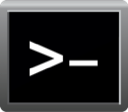 Databricks CLI commands take the bundle from check to running. Click a command to highlight the part of the `databricks.yml` it acts on.
<style>
.d1g { display:grid; grid-template-columns:minmax(300px,1fr) minmax(0,1fr); gap:22px; max-width:1150px; margin:0 auto; font-family:sans-serif; align-items:start; }
.d1left { display:flex; flex-direction:column; gap:16px; min-width:0; }
.d1step { position:relative; cursor:pointer; padding-left:44px; user-select:none; }
.d1badge { position:absolute; left:0; top:0; width:30px; height:30px; border-radius:50%; background:#FF5F46; color:#fff; font-weight:700; font-size:14pt; display:flex; align-items:center; justify-content:center; }
.d1cmd { background:#0b2026; color:#fff; font-family:Consolas,Monaco,monospace; font-size:13pt; padding:9px 14px; border-radius:4px; word-break:break-word; border:2px solid transparent; }
.d1step.active .d1cmd { border-color:var(--cc); }
.d1desc { font-size:12.5pt; color:#0b2026; margin-top:6px; line-height:1.4; }
.d1right { min-width:0; }
.d1pre { background:#f8f8f8; border:1px solid #e0e0e0; border-radius:8px; padding:14px 16px; margin:0; overflow-x:auto; font-family:Consolas,Monaco,monospace; font-size:12pt; line-height:1.5; color:#1B3139; }
.d1ln { display:block; white-space:pre; padding:0 6px; border-radius:3px; transition:background .15s; }
@media (max-width:780px){ .d1g{ grid-template-columns:1fr; } }
</style>
<div class="d1g">
  <div class="d1left"><div class="d1step" data-idx="0" data-lines="0,1,2,3" style="--cc:#4299E0;" onclick="d1sel(0)"><div class="d1badge">1</div><div class="d1cmd">databricks bundle <b>validate</b></div><div class="d1desc">Returns <b>warnings</b> if unknown resource properties are found in bundle configuration files.</div></div><div class="d1step" data-idx="1" data-lines="13,14,15,16,17,18" style="--cc:#00A972;" onclick="d1sel(1)"><div class="d1badge">2</div><div class="d1cmd">databricks bundle <b>deploy -t development</b></div><div class="d1desc">Specifies which environment to <b>deploy</b> your bundle into. In this example, the bundle will be deployed to the <b>development</b> environment.</div></div><div class="d1step" data-idx="2" data-lines="4,5" style="--cc:#FFAB00;" onclick="d1sel(2)"><div class="d1badge">3</div><div class="d1cmd">databricks bundle <b>run -t development l1_simple_dab</b></div><div class="d1desc">Specifies to run your bundle in the environment. You must specify the <b>job key name</b> to run the bundle job.</div></div></div>
  <div class="d1right"><div style="font-size:12pt;color:#5E7077;font-style:italic;margin-bottom:6px;">databricks.yml</div><pre class="d1pre"><span class="d1ln" data-ln="0">bundle:</span><span class="d1ln" data-ln="1">  name: demo01_bundle</span><span class="d1ln" data-ln="2"> </span><span class="d1ln" data-ln="3">resources:</span><span class="d1ln" data-ln="4">  jobs:</span><span class="d1ln" data-ln="5">    l1_simple_dab:</span><span class="d1ln" data-ln="6">      name: my_job_name_l1_simple_dab</span><span class="d1ln" data-ln="7">      tasks:</span><span class="d1ln" data-ln="8">        - task_key: create_bronze_table</span><span class="d1ln" data-ln="9">          notebook_task:</span><span class="d1ln" data-ln="10">            notebook_path: ./src/create_bronze_table.py</span><span class="d1ln" data-ln="11">            source: WORKSPACE</span><span class="d1ln" data-ln="12">. . .</span><span class="d1ln" data-ln="13">targets:</span><span class="d1ln" data-ln="14">  development:</span><span class="d1ln" data-ln="15">    mode: development</span><span class="d1ln" data-ln="16">    default: true</span><span class="d1ln" data-ln="17">    workspace:</span><span class="d1ln" data-ln="18">      host: https://dev.cloud.databricks.com/</span></pre></div>
</div>
<script>
(function(){
  var COLORS=['rgba(66,153,224,0.22)', 'rgba(0,169,114,0.22)', 'rgba(255,171,0,0.22)'];
  window.d1sel=function(idx){
    document.querySelectorAll('.d1ln').forEach(function(s){ s.style.background=''; });
    document.querySelectorAll('.d1step').forEach(function(c){ c.classList.remove('active'); });
    var card=document.querySelector('.d1step[data-idx="'+idx+'"]'); if(!card) return; card.classList.add('active');
    card.getAttribute('data-lines').split(',').forEach(function(n){ var s=document.querySelector('.d1ln[data-ln="'+n+'"]'); if(s) s.style.background=COLORS[idx]; });
  };
  window.addEventListener('load',function(){ window.d1sel(0); });
})();
</script>

##### EXPAND FOR ADDITIONAL NOTES

<details>

_Speaker notes:_

- Now that we have a good understanding of the databricks.yml file, let's explore how to validate, deploy, and run our Declarative Automation Bundles.
- First, you'll want to validate your bundle. You can do this with the Databricks CLI command databricks bundle validate.
- Next, you'll deploy the bundle to your Databricks Workspace. To do this, use the databricks bundle deploy command, the -t flag for target, and specify the environment you want to deploy to. In this example, we will deploy to the development environment. By default, development is set as the default target, so if you don't specify where to deploy, it will go to development. However, it's best practice to be explicit.
- Once the bundle is deployed to Databricks, you will typically want to run it. To run the job in the bundle, use the databricks bundle run command, the -t flag for development, and the key that specifies the job to run. Here the key is l1_simple_dab.
- And that's it! We've covered how to create, validate, deploy, and run a simple Declarative Automation Bundle!

</details>

## E. Conclusion

- A **DAB** describes a Databricks project (code, resources, configuration) in YAML and is driven by the Databricks CLI, useful in development and CI/CD.
- A bundle project follows a standard structure: `databricks.yml`, `resources/`, `src/`, and `tests/`.
- The `databricks.yml` top-level mappings, especially **bundle**, **resources**, and **targets**, define the bundle.
- Three CLI commands, **validate**, **deploy**, and **run**, take a bundle from check to execution.

### Next Steps

In the next demo, you will deploy a simple DAB and see these commands in action.


&copy; 2026 Databricks, Inc. All rights reserved. Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>